## Investigation of Reinforcement Learning Approach 
- Training set size and diversity
- Training curves, validation and training loss

In [1]:
from models.goal_directed_lstm import GoalDirectedLSTM
from experiment_runner import ExperimentRunner
import torch
import pandas as pd
import numpy as np
from base_experiment import BaseExperiment
from trajectory import TrajectoryRecord
from experiment_config import ExperimentConfig
from models import oracle, random_forest, goal_directed_lstm, mlp
from assets.data_ops import (
    load_data, build_tfbind8_dataframe, encode_sequence, 
    one_hot_encode_sequence, decode_sequence
)


/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
def _setup_gb1():
        """Setup GB1 dataset."""
        alphabet = list("ACDEFGHIKLMNPQRSTVWY")
        token_to_idx = {token: idx for idx, token in enumerate(alphabet)}
        
        _oracle = oracle.load_GB1_oracle()

        df = load_data(name="gb1")
        # Score the whole dataset with oracle and add scores to dataframe
        

        #print binding score range
        print(f"Binding score range: {df['binding_scores'].min()} - {df['binding_scores'].max()}")

        # Select training data, all sequences where binding_socres are lower than 50percent quantile of the binding scores in the dataset
        train_df = df[df["split"] == "train"].copy()
  
        # print some statistics about the training data
        print(f"Training data size: {len(train_df)}")
        print(f"Training data binding score max: {train_df['binding_scores'].max()}")
        

        # Prepare training data
        X_train = np.array([
            encode_sequence(seq, token_to_idx) 
            for seq in train_df["sequence"]
        ])
        
        # Score training sequences with oracle
        y_train = _oracle.score_batch(train_df["sequence"])

        # mix sequences from split "test_a, "test_b", "test_c" for a validataion dataset
        val_df = df[df["split"].isin(["test_a", "test_b", "test_c"])].copy()

        # select 20% of the validation data for validation
        val_df = val_df.sample(frac=0.02, random_state=42)    

        X_val = np.array([encode_sequence(seq, token_to_idx)
                          for seq in val_df["sequence"]])
        y_val = _oracle.score_batch(val_df["sequence"])

        return X_train, y_train, X_val, y_val


def _train_goal_directed_model(lstm_model, loader, val_loader, epochs=100, lr=0.001, entropy_weight=0.01):
        """Train LSTM with entropy regularization."""
        optimizer = torch.optim.Adam(lstm_model.parameters(), lr=lr)
        criterion = torch.nn.CrossEntropyLoss()
        
        lstm_model.train()
        
        history = []
        val_history = []

        for epoch in range(epochs):
            epoch_loss = 0
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                
                input_seq = batch_x[:, :-1]
                target_part = batch_x[:, 1:]
                logits, _ = lstm_model(input_seq, batch_y)
                
                ce_loss = criterion(
                    logits.reshape(-1, lstm_model.vocab_size), 
                    target_part.reshape(-1)
                )
                
                # Entropy regularization
                probs = torch.softmax(logits, dim=-1)
                entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=-1).mean()
                loss = ce_loss - entropy_weight * entropy
                
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            history.append(epoch_loss / len(loader))
            
            lstm_model.eval()
            with torch.no_grad():
                val_loss = 0
                for val_x, val_y in val_loader:
                    input_seq = val_x[:, :-1]
                    target_part = val_x[:, 1:]
                    goal_scores = val_y.float().unsqueeze(1)
                    logits, _ = lstm_model(input_seq, val_y)
                    ce_loss = criterion(
                        logits.reshape(-1, lstm_model.vocab_size), 
                        target_part.reshape(-1)
                    )
                    val_loss += ce_loss.item()
                val_history.append(val_loss / len(val_loader))
            lstm_model.train()
            if epoch % 10 == 0: 
                print(f'Pretraining epoch {epoch}/{epochs}, Loss: {epoch_loss/len(loader):.4f}')
        return history, val_history

In [28]:
X_train, y_train, X_val, y_val = _setup_gb1()

print(f'Training data size: {len(X_train)}, Validation data size: {len(X_val)}')

alphabet = list("ACDEFGHIKLMNPQRSTVWY")
token_to_idx = {token: idx for idx, token in enumerate(alphabet)}
seq_length = X_train.shape[1]

print(f'Vocabulary size: {len(token_to_idx)}, Sequence length: {seq_length}')

Binding score range: -11.202243186187722 - 3.602644083396247
Training data size: 16244
Training data binding score max: -2.7896733393825137
Training data size: 16244, Validation data size: 10290
Vocabulary size: 20, Sequence length: 55


In [ ]:
lstm_model = lstm_model = goal_directed_lstm.GoalDirectedLSTM(
            vocab_size=len(token_to_idx),
            embedding_dim=32,
            sequence_length=seq_length,
            hidden_dim=128,
            goal_score = 1
        )
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).view(-1, 1)

train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=20, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=20, shuffle=False)

history, val_history = _train_goal_directed_model(lstm_model, train_loader, val_loader, epochs=20, lr=1e-3, entropy_weight=0.1)

Pretraining epoch 0/60, Loss: 0.3556
Pretraining epoch 10/60, Loss: 0.1529
Pretraining epoch 20/60, Loss: 0.1487
Pretraining epoch 30/60, Loss: 0.1431
Pretraining epoch 40/60, Loss: 0.1411
Pretraining epoch 50/60, Loss: 0.1390


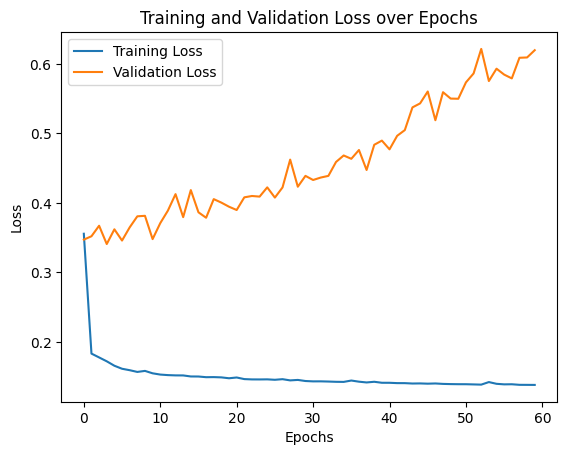

In [26]:
# plot history, val_history loss and training loss over epochs
import matplotlib.pyplot as plt
plt.plot(history, label='Training Loss')

plt.plot(val_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

In [1]:
import mavenn
data = mavenn.load_example_dataset('gb1')
# print out score range of y 
print(f"Binding score range: {data['y'].min()} - {data['y'].max()}")

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Binding score range: -11.202243186187722 - 3.602644083396247
